# 05 - CNN from Scratch|

1. **original** - `data/split`
2. **CLAHE** - `data/enhanced/clahe`
3. **Gaussian** - `data/enhanced/gaussian`
4. **CLAHE + Gaussian** - `data/enhanced/clahe_gaussian`
5. **GrabCut** (segmentasi) - `data/segmented_grabcut`

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif, konfigurasi :", exc)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Konfigurasi & Path

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, accuracy_score,
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 20
keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("..").resolve()

DIR_ORIGINAL = PROJECT_ROOT / "data" / "split"

DIR_CLAHE = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe"
)

DIR_CLAHE_GAUSSIAN = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe_gaussian"
)

EXPECTED_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
NUM_CLASSES = len(EXPECTED_CLASSES)

DIR_METRICS = PROJECT_ROOT / "results" / "metrics"
DIR_FIGURES = PROJECT_ROOT / "results" / "figures"
for d in (DIR_METRICS, DIR_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

print("Skenario yang akan diuji:")
for nama, p in SCENARIOS.items():
    print(f"  {nama:16s} -> {p}  (ada: {p.exists()})")

Skenario yang akan diuji:
  original         -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\split  (ada: True)
  clahe            -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe  (ada: True)
  gaussian         -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\gaussian  (ada: False)
  clahe_gaussian   -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe_gaussian  (ada: True)
  grabcut          -> D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\segmented_grabcut  (ada: False)


## 2. Model & Util

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def load_scenario(base_dir):
    def load(split, shuffle):
        return keras.utils.image_dataset_from_directory(
            base_dir / split, labels="inferred", label_mode="int",
            image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED)
    tr = load("train", True); va = load("val", False); te = load("test", False)
    names = tr.class_names
    assert names == EXPECTED_CLASSES, f"Urutan kelas tak sesuai: {names}"
    return (tr.cache().prefetch(AUTOTUNE), va.cache().prefetch(AUTOTUNE),
            te.cache().prefetch(AUTOTUNE))

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")

def build_baseline_cnn():
    """CNN baseline identik dengan notebook 05 (agar adil)."""
    keras.utils.set_random_seed(SEED)
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x); x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_baseline")
    model.compile(optimizer=keras.optimizers.Adam(),
                  loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=["accuracy"])
    return model

def compute_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
            "precision_macro": round(float(p), 4),
            "recall_macro": round(float(r), 4),
            "f1_macro": round(float(f), 4)}

def eval_on_test(model, ds_test):
    yt, yp = [], []
    for xb, yb in ds_test:
        pr = model.predict(xb, verbose=0).argmax(axis=1)
        yt.extend(yb.numpy().tolist()); yp.extend(pr.tolist())
    return np.array(yt), np.array(yp)

## 3. Loop Training

In [8]:
hasil = []
cms = {}
for nama, base_dir in SCENARIOS.items():
    if not base_dir.exists():
        print(f"[SKIP] {nama}: folder tidak ada ({base_dir})")
        continue
    print("SKENARIO:", nama.upper())
    ds_tr, ds_va, ds_te = load_scenario(base_dir)
    model = build_baseline_cnn()
    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    ]
    model.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS, callbacks=cbs, verbose=1)
    yt, yp = eval_on_test(model, ds_te)
    m = compute_metrics(yt, yp)
    m.update({"scenario": nama, "model": "cnn_baseline"})
    hasil.append(m)
    cms[nama] = confusion_matrix(yt, yp, labels=range(NUM_CLASSES))
    print(f"[{nama}] test:", {k: m[k] for k in ("accuracy", "f1_macro")})
    del model
    keras.backend.clear_session()  

SKENARIO: ORIGINAL
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 123s 354ms/step - accuracy: 0.2765 - loss: 1.6586 - val_accuracy: 0.3192 - val_loss: 1.6018 - learning_rate: 0.0010
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 114s 338ms/step - accuracy: 0.3460 - loss: 1.5660 - val_accuracy: 0.3382 - val_loss: 1.5691 - learning_rate: 0.0010
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 105s 310ms/step - accuracy: 0.3920 - loss: 1.5001 - val_accuracy: 0.3858 - val_loss: 1.5185 - learning_rate: 0.0010
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 90s 265ms/step - accuracy: 0.4540 - loss: 1.4221 - val_accuracy: 0.4282 - val_loss: 1.4731 - learning_rate: 0.0010
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 100s 295ms/step - accuracy: 0.4841 - loss: 1.3600 - val_accuracy: 0.4766 - val_loss: 1.3742 - learning_rate: 0.0010
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 101s 300ms/step - accuracy: 0.5170 - lo

## 4. Tabel & Grafik Perbandingan

In [9]:
df = pd.DataFrame(hasil)[["scenario", "model", "accuracy",
                          "precision_macro", "recall_macro", "f1_macro"]]
df = df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
df.to_csv(DIR_METRICS / "enhancement_comparison_metrics.csv", index=False)
print("Disimpan:", DIR_METRICS / "enhancement_comparison_metrics.csv")
display(df)

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\metrics\enhancement_comparison_metrics.csv


,scenario,model,accuracy,precision_macro,recall_macro,f1_macro
0,clahe_gaussian,cnn_baseline,0.6379,0.6560,0.6503,0.6489
1,gaussian,cnn_baseline,0.6318,0.6607,0.6324,0.6439
2,clahe,cnn_baseline,0.6361,0.6480,0.6376,0.6397
3,original,cnn_baseline,0.5929,0.6015,0.5918,0.5909
4,grabcut,cnn_baseline,0.5402,0.5596,0.5159,0.5233


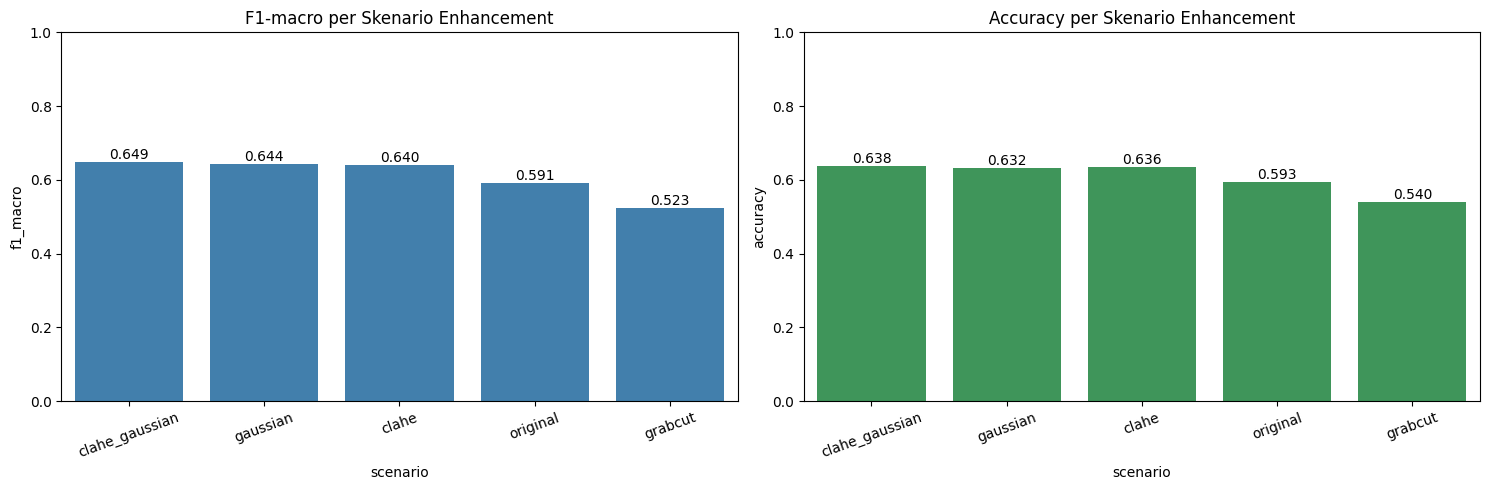

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
order = df.sort_values("f1_macro", ascending=False)
sns.barplot(data=order, x="scenario", y="f1_macro", ax=ax[0], color="#3182bd")
ax[0].set_title("F1-macro per Skenario Enhancement"); ax[0].set_ylim(0, 1)
ax[0].bar_label(ax[0].containers[0], fmt="%.3f")
sns.barplot(data=order, x="scenario", y="accuracy", ax=ax[1], color="#31a354")
ax[1].set_title("Accuracy per Skenario Enhancement"); ax[1].set_ylim(0, 1)
ax[1].bar_label(ax[1].containers[0], fmt="%.3f")
for a in ax:
    a.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(DIR_FIGURES / "enhancement_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

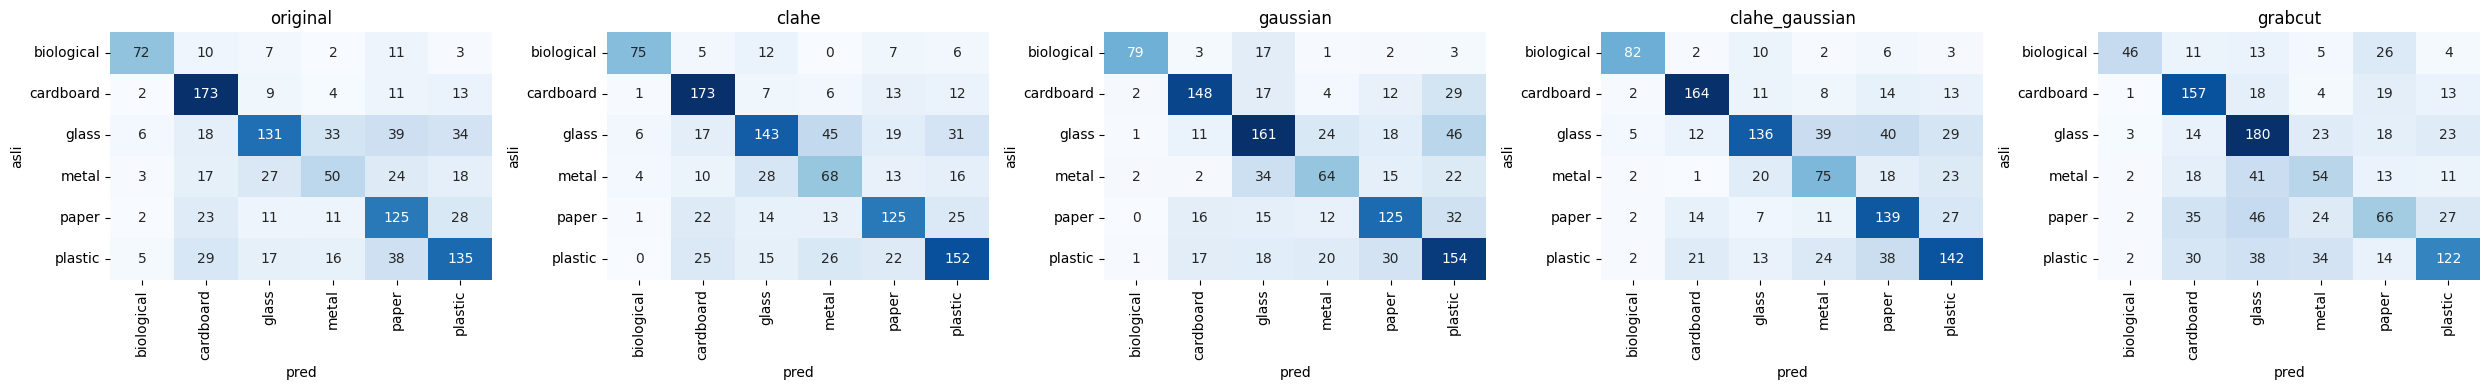

In [11]:
# Confusion matrix tiap skenario 
n = len(cms)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]
for ax, (nama, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=EXPECTED_CLASSES, yticklabels=EXPECTED_CLASSES, ax=ax)
    ax.set_title(nama); ax.set_xlabel("pred"); ax.set_ylabel("asli")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(DIR_FIGURES / "enhancement_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()